In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

from cmdstanpy import CmdStanModel

## Data Import and Exploration

In [2]:
# Read the writing data file
df = pd.read_csv("WritingStudyFastSlow_long.csv", sep=";")

In [3]:
# Explore the top five rows
df.head()

,participant,condition,char,RT
0,AMS_04142025,D_fast,C,169
1,AMS_04142025,ND_fast,C,422
2,APM_04072025,D_fast,C,453
3,APM_04072025,ND_fast,C,591
4,ARI_04162025,D_fast,C,372


In [4]:
# and now the bottom 5 rows
df.tail()

,participant,condition,char,RT
1242,OMY_04202025,ND_slow,Z,2198
1243,TCO_03272025,D_slow,Z,840
1244,TCO_03272025,ND_slow,Z,1481
1245,YWG_03262025,D_slow,Z,372
1246,YWG_03262025,ND_slow,Z,813


In [5]:
df_D_fast = df[df["condition"] == "D_fast"].reset_index(drop=True)
df_ND_fast = df[df["condition"] == "ND_fast"].reset_index(drop=True)
df_D_slow = df[df["condition"] == "D_slow"].reset_index(drop=True)
df_ND_slow = df[df["condition"] == "ND_slow"].reset_index(drop=True)

Text(0, 0.5, 'Frequency')

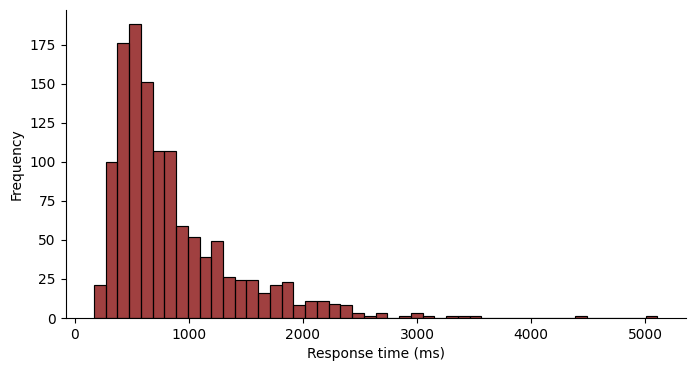

In [6]:
# Plot all the writing times in the dataset across all 4 conditions
rts = df.RT.values
f, ax = plt.subplots(1, 1, figsize=(8, 4))
sns.histplot(rts, color='maroon', ax=ax)
sns.despine(ax=ax)
ax.set_xlabel('Response time (ms)')
ax.set_ylabel('Frequency')

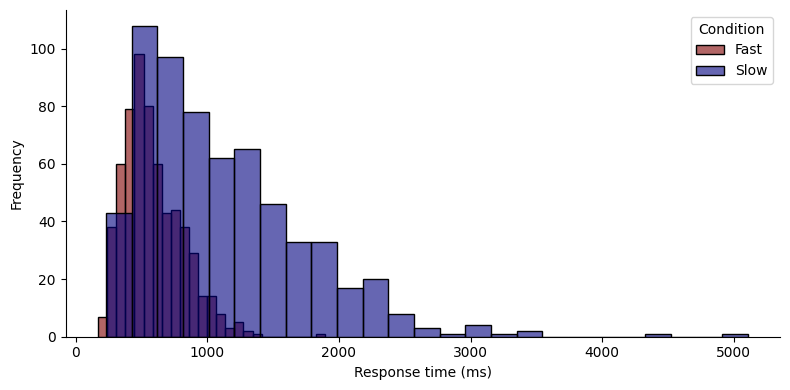

In [7]:
# Plot RTs for fast and slow conditions separately
rts_fast = df.RT[df.condition.str.contains('fast')].values
rts_slow = df.RT[df.condition.str.contains('slow')].values

f, ax = plt.subplots(1, 1, figsize=(8, 4))
sns.histplot(rts_fast, color='maroon', alpha=0.6, ax=ax, label='Fast')
sns.histplot(rts_slow, color='navy', alpha=0.6, ax=ax, label='Slow')
sns.despine(ax=ax)
ax.set_xlabel('Response time (ms)')
ax.set_ylabel('Frequency')
ax.legend(title='Condition')

f.tight_layout()

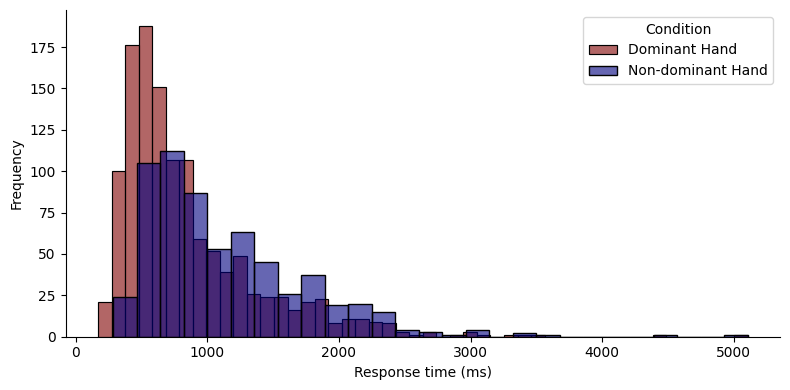

In [8]:
# Plot RTs for ND and D conditions separately
rts_D = df.RT[df.condition.str.contains('D_')].values
rts_ND = df.RT[df.condition.str.contains('ND_')].values

f, ax = plt.subplots(1, 1, figsize=(8, 4))
sns.histplot(rts_D, color='maroon', alpha=0.6, ax=ax, label='Dominant Hand')
sns.histplot(rts_ND, color='navy', alpha=0.6, ax=ax, label='Non-dominant Hand')
sns.despine(ax=ax)
ax.set_xlabel('Response time (ms)')
ax.set_ylabel('Frequency')
ax.legend(title='Condition')

f.tight_layout()

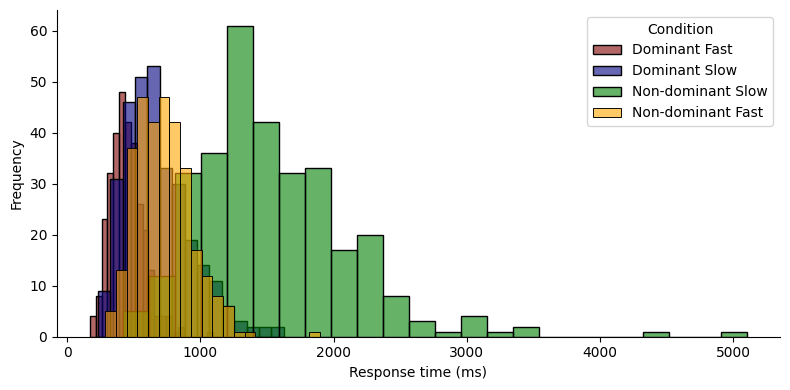

In [9]:
rts_Dfast = df_D_fast.RT.values
rts_Dslow = df_D_slow.RT.values
rts_NDfast = df_ND_fast.RT.values
rts_NDslow = df_ND_slow.RT.values

f, ax = plt.subplots(1, 1, figsize=(8, 4))
sns.histplot(rts_Dfast, color='maroon', alpha=0.6, ax=ax, label='Dominant Fast')
sns.histplot(rts_Dslow, color='navy', alpha=0.6, ax=ax, label='Dominant Slow')
sns.histplot(rts_NDslow, color='green', alpha=0.6, ax=ax, label='Non-dominant Slow')
sns.histplot(rts_NDfast, color='orange', alpha=0.6, ax=ax, label='Non-dominant Fast')
sns.despine(ax=ax)
ax.set_xlabel('Response time (ms)')
ax.set_ylabel('Frequency')
ax.legend(title='Condition')

f.tight_layout()

## Introduction

In this notebook, we will estimate the parameters of the simple diffusion model from a simulated response times (RTs) data set using Stan's implementation of Hamiltonian Monte Carlo (HMC). But, wait! Since we are simulating the data (i.e., solving the forward problem), don't we already know the parameters with absolute certainty? Indeed, in this case we do, and this little exercise will introduce a crucial principle of all computational modeling: **Parametric models are nothing but assumptions about the unknown data-generating process**, so, in a way, the inverse problem (i.e., going from data to parameters) presupposes the forward problem. 

Thus, even when we are estimating the parameters from an actually observed data set, we are assuming that the parametric model is the accurate description of the system that generated the data. In other words, we hope that our model is *well-specified*. Simulation studies enable science *in silico*, that is, before collecting any data, we can already play oracles and test what we can learn from the data by successively solving the forward and the inverse problem.

## Diffusion Model Simulator

In [10]:
def simulate_diffusion(v, a, beta, tau, T=0, dt=1, scale=100, max_time=6000, rng=None):
    """
    Simulates one realization of the diffusion process given
    a set of parameters and a step size `dt`.

    Parameters:
    -----------
    v        : float
        The drift rate (rate of information uptake)
    a        : float
        The boundary separation (decision threshold).
    beta     : float in [0, 1]
        Relative starting point (prior option preferences)
    tau      : float
        Non-decision time (additive constant)
    dt       : float, optional (default: 1e-3 = 0.001)
        The step size for the Euler algorithm.
    scale    : float, optional (default: 1.0)
        The scale (sqrt(var)) of the Wiener process. Not considered
        a parameter and typically fixed to either 1.0 or 0.1.
    max_time : float, optional (default: .10)
        The maximum number of seconds before forced termination.
    rng      : np.random.Generator or None, optional (default: None)
        A random number generator with locally set seed or None
        If None provided, a new generator will be spawned within the function.
        
    Returns:
    --------
    num_steps : the total simulated writing time (RT)
    """

    # Inits (process starts at relative starting point)
    y = beta * a
    num_steps = tau + T
    const = scale*np.sqrt(dt)
    if rng is None:
        rng = np.random.default_rng()

    # Loop through process and check boundary conditions
    while (y <= a) and num_steps <= max_time:

        # Perform diffusion equation
        #z = abs(rng.normal()) # return absolute because there is only one threshold
        z = rng.normal()
        y += v*dt + const*z

        # Increment step counter
        num_steps += dt

    return num_steps

## Helper Functions

In [11]:
def simulate_diffusion_n(num_sims, v, a, beta, tau, T=0, dt=1, scale=1.0, max_time=6000, rng=None):
    """Add a nice docstring."""

    # Inits
    data = np.zeros(num_sims)
    if rng is None:
        rng = np.random.default_rng()
    
    # Create data set
    for n in range(num_sims):
        data[n] = simulate_diffusion(v, a, beta, tau, T, dt, scale, max_time, rng)
    return data


def visualize_data(data_Dfast, data_Dslow,data_NDfast, data_NDslow, figsize=(10, 5)):
    """Helper function to visualize a simple response time data set."""

    f, ax = plt.subplots(1, 1, figsize=figsize)
    sns.histplot(data_Dfast, color='maroon', alpha=0.6, ax=ax, label='Dominant Fast')
    sns.histplot(data_Dslow, color='navy', alpha=0.6, ax=ax, label='Dominant Slow')
    sns.histplot(data_NDslow, color='green', alpha=0.6, ax=ax, label='Non-dominant Slow')
    sns.histplot(data_NDfast, color='orange', alpha=0.6, ax=ax, label='Non-dominant Fast')
    sns.despine(ax=ax)
    ax.set_xlabel('Response time (ms)')
    ax.set_ylabel('Frequency')
    ax.legend(title='Condition')

    f.tight_layout()

    # f, axarr = plt.subplots(1, 2, figsize=figsize)
    
    # Histogram of response times
    # sns.histplot(
    #     data= data_fast, ax=axarr[0], color='#AA0000', alpha=0.8, lw=2, label=f'Fast Condition RTs')
    # sns.histplot(
    #     data= data_slow, ax=axarr[0], color='#0000AA', alpha=0.8, lw=2, label=f'Slow Condition RTs')

    # # Labels and embelishments
    # axarr[0].set_xlabel('Response time (s)', fontsize=16)
    # axarr[0].legend(fontsize=16)
    # axarr[0].set_ylabel('Count', fontsize=16)
    # axarr[1].set_xlabel('Response', fontsize=16)
    # axarr[1].set_ylabel('Frequency', fontsize=16)
    # for ax in axarr:
    #     sns.despine(ax=ax)
    #     ax.grid(alpha=0.1, color='black')

    # f.suptitle('Data Summary', fontsize=18)

    # f.tight_layout()

In [24]:
# Ensure reproducibility
RNG = np.random.default_rng(2024)

# Set ground-truth parameters
D_fast_parameters = {
    'v': 1.6,
    'a': 500,
    'beta': 0.5,
    'tau': 300,
    'T': 0
}

D_slow_parameters = {
    'v': 1,
    'a': 500,
    'beta': 0.5,
    'tau': 300,
    'T': 0
}

ND_fast_parameters = {
    'v': 1,
    'a': 500,
    'beta': 0.5,
    'tau': 300,
    'T': 100
}

ND_slow_parameters = {
    'v': 0.5,
    'a': 1300,
    'beta': 0.5,
    'tau': 300,
    'T': 100
}

# Set additional simulation settings
control = {
    'num_sims': 120,
    'rng': RNG,
    'dt': 1
}

# Create data with above configuration
# Match dictionary keys automatically with **
data_Dfast = simulate_diffusion_n(**{**control, **D_fast_parameters})
data_Dslow = simulate_diffusion_n(**{**control, **D_slow_parameters})
data_NDfast = simulate_diffusion_n(**{**control, **ND_fast_parameters})
data_NDslow = simulate_diffusion_n(**{**control, **ND_slow_parameters})


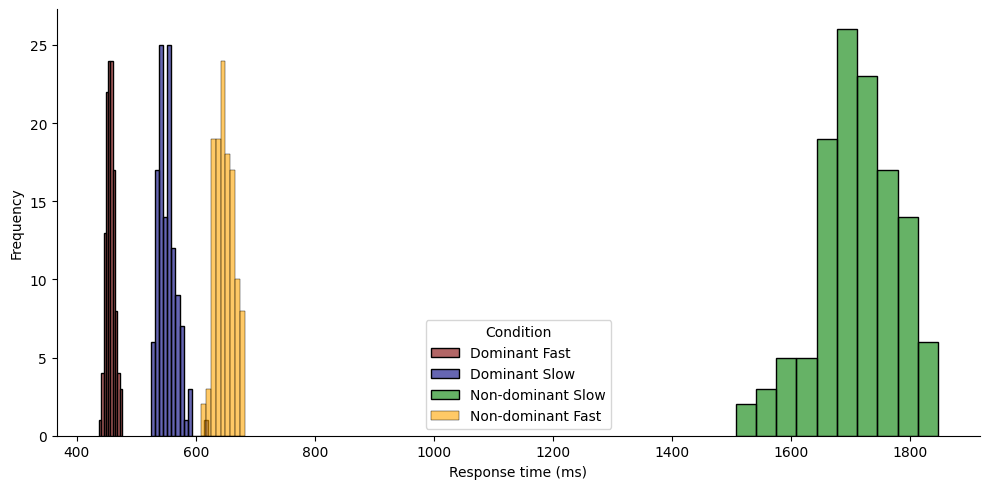

In [25]:
visualize_data(data_Dfast, data_Dslow, data_NDfast, data_NDslow)

## Bayesian Parameter Estimation

Now, we will write a Stan program to sample from the posterior of the diffusion model parameters given the observed data.

### Prior Distributions

In [ ]:
### Visualizing our priors
f, axarr = plt.subplots(1, 4, figsize=(12, 3))
param_names = [r'Drift rate ($v$)', r'Boundary separation ($a$)', r'Bias ($\beta$)', r'Non-decision time ($\tau$)']
sns.histplot(np.random.gamma(3, 1, size=100000), color='maroon', ax=axarr[0])
sns.histplot(np.random.gamma(3, 1, size=100000), color='maroon', ax=axarr[1])
sns.histplot(np.random.beta(2, 2, size=100000), color='maroon', ax=axarr[2])
sns.histplot(np.random.gamma(2, 1, size=100000), color='maroon', ax=axarr[3])

for ax, p in zip(axarr, param_names):
    ax.set_title(p, fontsize=14)
    ax.set_xlabel('Parameter value', fontsize=12)
    ax.set_yticks([])
    ax.set_ylabel('')
    sns.despine(ax=ax)

f.tight_layout()

## Stanpower

### Compilation and Sampling

In [ ]:
import os

os.listdir("./")

In [ ]:
# Prepare data in Stan friendly format
rts_fast = df.RT[df.condition.str.contains('fast')].values
rts_slow = df.RT[df.condition.str.contains('slow')].values

print(rts_slow.shape)

data_dict = {
    'y_fast': rts_fast, 
    'y_slow': rts_slow, 
    'N_fast': rts_fast.shape[0],
    'N_slow': rts_slow.shape[0]
}

# Compile model
model = CmdStanModel(stan_file="./writing_time_diffusion_model.stan")

In [ ]:
# Approximate posterior
fit = model.sample(
    data=data_dict, 
    chains=4, 
    iter_warmup=500, 
    iter_sampling=1000, 
)

In [ ]:
print(fit.diagnose())

In [ ]:
# Posterior summary statistics
az.summary(fit)

In [ ]:
parameters

In [ ]:
# Extract samples
df = fit.draws_pd()

In [ ]:
# Traceplots 
f = az.plot_trace(fit, compact=False, legend=True)
plt.tight_layout()

## Real-Data Application

In [ ]:
# Reading in example response times (RT) data
df = pd.read_csv('rt_example_data.csv', delimiter=';')

In [ ]:
df

In [ ]:
### Your code here
data_dict = {
    'y': df['RT'], 
    'c': df['RESPONSE'],
    'N': df.shape[0]
}

In [ ]:
model = CmdStanModel(stan_file="./simple_diffusion.stan")

fit = model.sample(
    data=data_dict, 
    chains=4, 
    iter_warmup=500, 
    iter_sampling=1000, 
)

In [ ]:
print(fit.diagnose())

In [ ]:
az.summary(fit)